# Chapter 30 — RASDR & Talking to Radio-Sky Spectrograph

In [Chapter 16](16_data_formats_and_ecosystem.ipynb) we toured the radio-data
*format landscape* — GUPPI raw, SigMF, the visibility formats — and met the
**Radio-Sky Spectrograph (RSS) network protocol** for the first time, streaming a
simulated decametric storm to an in-process mock server. This chapter zooms in on
**one real receiver and the exact path its samples take to reach a human's screen**:
**RASDR → Radio-Sky Spectrograph over TCP**.

The goal is to make that data path concrete. By the end you will have:

- a clear picture of what **RASDR** is (an amateur **Radio Astronomy SDR**) and where
  it sits in the amateur radio-astronomy software ecosystem;
- streamed a realistic, **Jupiter-like decametric burst** through the *genuine* RSS
  wire format and recovered it **byte-for-byte**;
- inspected the **raw bytes** of a single sweep so the `F|S|O|C` handshake, the LoHi
  `uint16` encoding, and the `0xFE 0xFE` terminator stop being abstractions;
- a clearly-marked recipe for pointing the same code at the **real** Radio-Sky
  Spectrograph application, with no change to the streaming logic.

> **Everything here runs fully offline.** We use
> [`jansky.formats.MockRSSServer`](https://github.com/joebarbere/jansky/blob/main/src/jansky/formats.py),
> an in-process stand-in for RSS. **No SDR, no LimeSDR, no network, no RSS install is
> required** — the real hardware and software are *optional*, and the final section
> tells you exactly how to swap them in.

## 1. Orientation — what RASDR is, and the ecosystem it lives in

**RASDR — "Radio Astronomy SDR"** — is an open, amateur radio-astronomy receiver
project from [**myriadrf**](https://github.com/myriadrf/RASDR) (the community behind
the [LimeSDR](https://myriadrf.org/projects/limesdr/) software-defined radio). At its
heart is a **LimeSDR / LMS7002M** transceiver chip; RASDR wraps it with software that
channelises the incoming RF into a power **spectrum** and streams those spectra out for
display and recording. It is aimed squarely at the amateur radio-astronomy bands —
think the **decametric (~20 MHz)** emission from **Jupiter** and the **Sun** that the
[NASA Radio JOVE](https://radiojove.gsfc.nasa.gov/) community chases (see
[Chapter 23: The Sun & Jupiter](23_solar_and_jupiter.ipynb)).

Where does the data *go*? RASDR does not draw its own pretty waterfalls — it hands the
spectra to a **display program**. The de-facto standard in this community is
[**Radio-Sky Spectrograph (RSS)**](https://radiosky.com/), a Windows application that
draws live **dynamic spectra** (a waterfall of power vs. frequency vs. time). RASDR
talks to RSS over a plain **TCP socket**, and *that socket is the data path this whole
chapter is about*:

```
   antenna ──▶ LimeSDR (RASDR hardware) ──▶ RASDR software (channelise → spectra)
                                                     │
                                                     │  TCP, 127.0.0.1:8888
                                                     ▼
                                        Radio-Sky Spectrograph (display + record)
```

The amateur RA software ecosystem around this is small and friendly:

| Piece | Role |
|---|---|
| **RASDR** (myriadrf) | LimeSDR-based receiver; produces spectra, *is the TCP client* |
| **Radio-Sky Spectrograph (RSS)** | display/record program; *is the TCP server on :8888* |
| **Radio-SkyPipe** | companion strip-chart recorder (`.spd`) |
| **Radio JOVE** (NASA) | the education project these tools serve — Jupiter & Sun at ~20 MHz |

This chapter is the practical companion to two reference pages in the course:
[**`docs/data-formats.md`**](https://github.com/joebarbere/jansky/blob/main/docs/data-formats.md)
(the RSS protocol spec, and why the `.sps`/`.spd` *file* readers are deferred) and
[**`docs/projects.md`**](https://github.com/joebarbere/jansky/blob/main/docs/projects.md)
(the Radio JOVE kit and the wider hardware landscape).

> **The real hardware is optional.** You do **not** need a LimeSDR, an antenna, or a
> Windows machine running RSS to do everything below. We simulate the spectra RASDR
> *would* produce and stream them through the real protocol into a mock server. If you
> *do* own the hardware, §4 shows the one-line change to point at the real thing.

## 2. The RASDR → Radio-Sky data path

We met the **RSS network protocol** in [Chapter 16](16_data_formats_and_ecosystem.ipynb);
here is the compact recap, framed as *what RASDR actually does on the wire*. The
protocol is documented in
["How to Talk to Radio-Sky Spectrograph"](http://cygnusa.blogspot.com/2015/07/how-to-talk-to-radio-sky-spectrograph.html)
and pinned down by the
[**RASDR socket commit**](https://github.com/myriadrf/RASDR/commit/61676c46aee677ad215d5187084a92b41269834f)
in myriadrf's source — RASDR is the canonical client.

**The conversation has exactly two parts.**

**(a) The `F | S | O | C` handshake.** On connecting to RSS (which listens on
**`127.0.0.1:8888`**), the client sends a single ASCII line of `key value|` pairs:

```
F <center_Hz>|S <span_Hz>|O <offset_Hz>|C <n_channels>|
```

- **`F`** — centre frequency in Hz (e.g. `20100000` for the 20.1 MHz decametric band);
- **`S`** — the total spectral span (sample rate / bandwidth) in Hz;
- **`O`** — a frequency offset in Hz (usually `0`);
- **`C`** — the channel count (RSS accepts **100–512** channels per sweep).

This tells RSS how wide each sweep is and how to label its frequency axis. No reply is
expected.

**(b) The sweeps.** After the handshake, RASDR streams **one sweep per integration**,
back to back, forever. Each sweep is:

- **`C` little-endian (`"LoHi"`) `uint16` samples** — 12-bit data, so each value is in
  `0..4095` (low byte first, then high byte);
- ordered **highest channel first** (the RSS waterfall expects high frequency at one
  edge, so the stream is reversed relative to a natural low→high array);
- terminated by the two bytes **`0xFE 0xFE`**.

There are **no timestamps and no acknowledgements** — timing is implicit in arrival
order, and the receiver just keeps shovelling sweeps. A sweep of `C` channels is
therefore exactly `2*C + 2` bytes on the wire.

`jansky.formats` implements **both ends** of this: an `RSSClient` (plays the role of
RASDR) and a `MockRSSServer` (plays the role of RSS), so we can exercise the *exact*
wire format with nothing installed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from jansky import formats, plotting

plotting.use_jansky_style()

# Reproducible simulation throughout this chapter.
SEED = 30
rng = np.random.default_rng(SEED)

# The four helpers we lean on -- all from jansky.formats:
#   rss_handshake   -> builds the "F|S|O|C" connect string (the bytes RASDR sends first)
#   encode_rss_sweep-> one spectrum -> LoHi uint16, high-channel-first, + 0xFE 0xFE
#   RSSClient       -> the TCP client (RASDR's role): connect(), send_sweep()
#   MockRSSServer   -> in-process stand-in for Radio-Sky Spectrograph (RSS's role)
print("RSS listens on port:", formats.RSS_DEFAULT_PORT)
print("sweep terminator   :", formats.RSS_TERMINATOR.hex(" "))
print("12-bit max value   :", formats.RSS_MAX_VALUE, "(0x%03X)" % formats.RSS_MAX_VALUE)

# A throwaway look at the handshake bytes RASDR would send for a 20.1 MHz, 256-ch run:
demo_handshake = formats.rss_handshake(20_100_000, 4_000_000, 256)
print("\nexample handshake :", demo_handshake.decode("ascii"))

RSS listens on port: 8888
sweep terminator   : fe fe
12-bit max value   : 4095 (0xFFF)

example handshake : F 20100000|S 4000000|O 0|C 256|


## 3. Stream a RASDR-style observation (simulated)

Now the main event. We will **simulate the spectra a RASDR receiver would produce while
pointed at the decametric sky**, stream them through `RSSClient` into a `MockRSSServer`,
and recover the dynamic spectrum on the other side — checking that **not a single byte
was lost**.

Chapter 16 simulated a smoothly *drifting* storm lane. Here we build something with a
different, very recognisable signature: a **Jupiter-like decametric burst** around
**20 MHz**. Jovian decametric (DAM) emission arrives in short, intense **storms** made
of **L-bursts** (smooth, seconds-long rises and falls) and finely structured **S-bursts**
(fast, drifting spikes). On an RSS waterfall this looks like bright, bursty vertical
streaks that switch on and off over a few minutes against a noisy background — exactly
the kind of thing a Radio JOVE observer records.

We render this directly into the **12-bit RSS count range (`0..4095`)** that the
protocol carries.

In [2]:
# --- A simulated RASDR observation: a Jovian decametric (DAM) storm at ~20 MHz ---
RSS_CENTER = 20_100_000      # Hz   -- centre of the decametric band (handshake "F")
RSS_SPAN   = 4_000_000       # Hz   -- total span / sample rate    (handshake "S")
RSS_OFFSET = 0               # Hz   -- frequency offset            (handshake "O")
RSS_NCHAN  = 256             # channels per sweep (RSS allows 100..512)  (handshake "C")
RSS_NSWEEP = 120             # sweeps (time samples) in this "observation"

chan = np.arange(RSS_NCHAN)
freq_mhz = (RSS_CENTER + (chan - RSS_NCHAN / 2) / RSS_NCHAN * RSS_SPAN) / 1e6

# Noise floor: a gently sloped galactic-background-ish baseline plus receiver noise.
baseline = 700 + 120 * (chan / RSS_NCHAN)            # mild spectral tilt

spectra = np.zeros((RSS_NSWEEP, RSS_NCHAN))
# Two Jovian "storms": bursty intervals during which bright emission switches on.
storm_windows = [(18, 42), (74, 104)]                # (start_sweep, end_sweep)

for t in range(RSS_NSWEEP):
    sweep = baseline + rng.normal(0, 35, RSS_NCHAN)  # noise floor for this sweep
    in_storm = any(a <= t < b for a, b in storm_windows)
    if in_storm:
        # L-burst: a broad, smooth envelope that breathes over the storm.
        env = 2300 * (0.6 + 0.4 * np.sin(0.4 * t))
        l_center = 110 + 8 * np.sin(0.15 * t)        # slow wander in frequency
        sweep += env * np.exp(-0.5 * ((chan - l_center) / 35) ** 2)
        # S-bursts: a handful of narrow, drifting spikes sprinkled across the band.
        for _ in range(rng.integers(2, 6)):
            c0 = rng.uniform(40, 220)
            amp = rng.uniform(1200, 2600)
            sweep += amp * np.exp(-0.5 * ((chan - c0) / 3.0) ** 2)
    spectra[t] = np.clip(sweep, 0, formats.RSS_MAX_VALUE)

print(f"simulated observation: {RSS_NSWEEP} sweeps x {RSS_NCHAN} channels")
print(f"values span [{spectra.min():.0f}, {spectra.max():.0f}] of 0..{formats.RSS_MAX_VALUE} (12-bit)")
print(f"handshake RASDR will send: {formats.rss_handshake(RSS_CENTER, RSS_SPAN, RSS_NCHAN, RSS_OFFSET).decode()}")

simulated observation: 120 sweeps x 256 channels
values span [576, 4095] of 0..4095 (12-bit)
handshake RASDR will send: F 20100000|S 4000000|O 0|C 256|


### Stand up the mock RSS, and let "RASDR" stream to it

The pattern below is exactly what real RASDR does, just with both ends in this process:

1. `MockRSSServer()` binds a socket (we let it pick an ephemeral port so the notebook
   never clashes with anything — the *real* RSS would be on `8888`);
2. `RSSClient(...)` connects and sends the `F|S|O|C` handshake automatically on
   `__enter__`;
3. each `send_sweep(...)` encodes one spectrum to LoHi `uint16`, high-channel-first,
   with the `0xFE 0xFE` terminator, and ships it;
4. `server.join()` waits for the server thread to finish parsing once the client
   disconnects, after which `server.config` and `server.sweeps` hold the recovered data.

In [3]:
# Stand up the in-process stand-in for Radio-Sky Spectrograph.
server = formats.MockRSSServer()        # binds 127.0.0.1 on an ephemeral port
server.start()
print(f"mock RSS server listening on {server.host}:{server.port}")

# Play RASDR: connect (sends the handshake), then stream every sweep.
with formats.RSSClient(
    center_hz=RSS_CENTER, bandwidth_hz=RSS_SPAN, n_channels=RSS_NCHAN,
    offset_hz=RSS_OFFSET, host=server.host, port=server.port,
) as rss:
    for sweep in spectra:
        rss.send_sweep(sweep)           # one sweep -> 2*C + 2 bytes on the wire

server.join()                           # wait for the server to finish parsing

print(f"\nserver parsed handshake config: {server.config}")
print(f"server received {len(server.sweeps)} sweeps")

mock RSS server listening on 127.0.0.1:42373

server parsed handshake config: {'F': 20100000, 'S': 4000000, 'O': 0, 'C': 256}
server received 120 sweeps


In [4]:
# --- Verify byte-for-byte recovery ---------------------------------------------
# (a) The handshake fields decoded by the server match exactly what we sent.
assert server.config["F"] == RSS_CENTER
assert server.config["S"] == RSS_SPAN
assert server.config["O"] == RSS_OFFSET
assert server.config["C"] == RSS_NCHAN
assert len(server.sweeps) == RSS_NSWEEP

# (b) The recovered sweeps match the (12-bit, integer) spectra we streamed,
#     channel-for-channel. encode/decode round-trips through the high-channel-first
#     ordering, so what comes out is back in natural low->high order.
recovered = np.array(server.sweeps)
expected  = np.rint(spectra).astype(int)
assert recovered.shape == expected.shape
assert np.array_equal(recovered, expected), "recovered sweeps differ from what was sent!"

print("Byte-for-byte recovery confirmed:")
print(f"  - handshake F/S/O/C all match")
print(f"  - {recovered.shape[0]} sweeps x {recovered.shape[1]} channels, identical to source")
print(f"  - every value survived the LoHi uint16 + 0xFE 0xFE round-trip")

Byte-for-byte recovery confirmed:
  - handshake F/S/O/C all match
  - 120 sweeps x 256 channels, identical to source
  - every value survived the LoHi uint16 + 0xFE 0xFE round-trip


### The recovered dynamic spectrum

This is the waterfall RSS would draw, reconstructed from the bytes that crossed the
socket. The two Jovian storms appear as bright, bursty intervals; the narrow drifting
S-burst spikes punch through the smoother L-burst envelope.

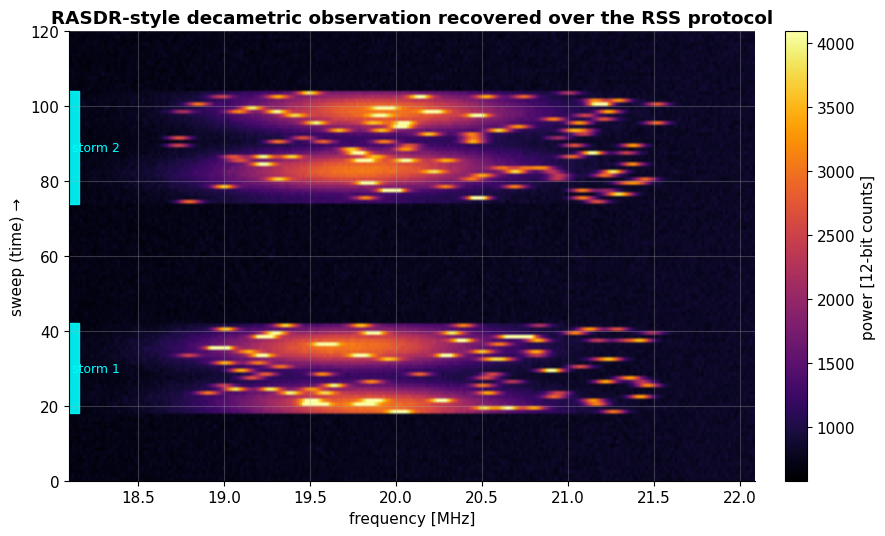

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(
    recovered, aspect="auto", origin="lower", cmap="inferno",
    extent=[freq_mhz[0], freq_mhz[-1], 0, RSS_NSWEEP],
)
# Mark the storm intervals on the time axis.
for a, b in storm_windows:
    ax.axhspan(a, b, xmin=0.0, xmax=0.015, color="cyan", alpha=0.9)
ax.set_xlabel("frequency [MHz]")
ax.set_ylabel("sweep (time) →")
ax.set_title("RASDR-style decametric observation recovered over the RSS protocol")
cb = fig.colorbar(im, ax=ax, label="power [12-bit counts]", fraction=0.046, pad=0.04)
ax.text(freq_mhz[1], 30, "storm 1", color="cyan", fontsize=9, va="center")
ax.text(freq_mhz[1], 89, "storm 2", color="cyan", fontsize=9, va="center")
fig.tight_layout()
plt.show()

## 4. Connecting to the real Radio-Sky Spectrograph

> **Optional — requires the real application and (optionally) RASDR/SDR hardware.**
> Everything above runs offline; this section is the bridge to a real setup. **Skip it
> with nothing lost** if you don't have RSS installed.

The beauty of the design is that **the streaming code above does not change at all** —
only the `host`/`port` you point `RSSClient` at. To feed the genuine application:

1. **Install and launch Radio-Sky Spectrograph** (Windows; runs under Wine on
   Linux/macOS) from [radiosky.com](https://radiosky.com/).
2. **Select the TCP/socket input.** In RSS, open
   **Options → Radio → RTL Bridge / TCP** (the network/"bridge" input). This is what
   makes RSS *listen* on `127.0.0.1:8888` for an external source — the role RASDR (or
   our `RSSClient`) plays.
3. **Choose your data source:**
   - **With RASDR hardware** (a LimeSDR running the RASDR software), RASDR *is* the
     client and connects to RSS for you — you simply observe.
   - **Without RASDR**, you can be the client yourself: point `RSSClient` at
     `127.0.0.1:8888` and stream spectra you compute from *any* SDR (an RTL-SDR,
     SDRplay, Airspy, …; see [`docs/projects.md`](https://github.com/joebarbere/jansky/blob/main/docs/projects.md)).

The code is identical to §3 — only `host` and `port` differ:

```python
# Point at the REAL Radio-Sky Spectrograph (do NOT run this offline).
with formats.RSSClient(center_hz=20_100_000, bandwidth_hz=4_000_000,
                       n_channels=256, host="127.0.0.1", port=8888) as rss:
    for sweep in your_spectra:        # each: 256 channel powers, 0..4095 (12-bit)
        rss.send_sweep(sweep)         # RSS draws each sweep as it arrives
```

That is the entire integration. Because `MockRSSServer` speaks the same protocol RSS
does, code that satisfies the mock will satisfy the real application unchanged — which
is exactly why we can develop and test the whole data path with no hardware.

In [6]:
# A guard you can keep in real scripts: only stream to the real RSS when asked to.
# Left as False so this notebook stays fully offline.
USE_REAL_RSS = False

if USE_REAL_RSS:
    # Requires Radio-Sky Spectrograph running with TCP/RTL-Bridge input selected.
    with formats.RSSClient(center_hz=RSS_CENTER, bandwidth_hz=RSS_SPAN,
                           n_channels=RSS_NCHAN, host="127.0.0.1", port=8888) as rss:
        for sweep in spectra:
            rss.send_sweep(sweep)
    print("streamed to the real Radio-Sky Spectrograph on 127.0.0.1:8888")
else:
    print("USE_REAL_RSS is False -> staying offline against MockRSSServer.")
    print("Flip it to True (with RSS running) to drive the real application.")

USE_REAL_RSS is False -> staying offline against MockRSSServer.
Flip it to True (with RSS running) to drive the real application.


## 5. Try it yourself

These all run offline against `MockRSSServer`. A small helper keeps the round-trip
boilerplate in one place so the exercises stay short.

In [7]:
def stream_through_mock(spectra, *, center_hz, span_hz, n_channels, offset_hz=0):
    """Stream `spectra` through RSSClient -> MockRSSServer and return (config, recovered).

    Plays the full RASDR -> RSS data path in-process: handshake, LoHi uint16 sweeps,
    0xFE 0xFE terminators -- entirely offline.
    """
    server = formats.MockRSSServer()
    server.start()
    with formats.RSSClient(center_hz=center_hz, bandwidth_hz=span_hz,
                           n_channels=n_channels, offset_hz=offset_hz,
                           host=server.host, port=server.port) as rss:
        for sweep in spectra:
            rss.send_sweep(sweep)
    server.join()
    return server.config, np.array(server.sweeps)

**Exercise 1 — change the handshake (channel count & centre frequency).**
RSS accepts **100–512** channels. Re-render a few sweeps at a *different* resolution and
a *different* centre frequency, stream them, and confirm the server's parsed
`config` echoes your new `F` and `C`. (What happens to `rss_handshake` if you ask for
`n_channels = 50`? Try it — the helper enforces the 100–512 range.)

<details>
<summary>Solution</summary>

The handshake is the `F | S | O | C` string that `rss_handshake` builds and `RSSClient`
sends on `__enter__`. To change the resolution and centre frequency you only change the
arguments you pass to `RSSClient` (here via `stream_through_mock`) — the wire format and
streaming logic are untouched. With `n_channels = 480` and `center_hz = 22_200_000` the
server parses back exactly:

```
{'F': 22200000, 'S': 6000000, 'O': 0, 'C': 480}
```

so `cfg["F"] == 22_200_000` and `cfg["C"] == 480`, and `rec.shape == (10, 480)`.

**Why the round-trip is faithful.** `C` is the only field that changes the *size* of each
sweep: a sweep is `2*C + 2` bytes on the wire (`C` LoHi `uint16` samples plus the
`0xFE 0xFE` terminator). For `C = 480` that is `2*480 + 2 = 962` bytes per sweep; the
server uses the handshake's `C` to know how many bytes to read before expecting the
terminator, which is exactly why `F | S | O | C` must arrive *first*.

**The `n_channels = 50` sub-question.** RSS only supports **100–512** channels per sweep,
and `rss_handshake` enforces that range *before any bytes are sent* — so a bad request
fails fast, on the client, rather than corrupting the stream:

```python
>>> formats.rss_handshake(22_200_000, 6_000_000, 50)
ValueError: RSS supports 100–512 channels
```

The bounds are inclusive: `100` and `512` are accepted, `50` and `513` are rejected.

</details>

In [8]:
# Exercise 1: a higher-resolution sweep at a different centre frequency.
EX_NCHAN  = 480                  # try values in 100..512
EX_CENTER = 22_200_000           # Hz, a different decametric centre
EX_SPAN   = 6_000_000            # Hz

ex_chan = np.arange(EX_NCHAN)
ex_spectra = np.clip(
    900 + 1800 * np.exp(-0.5 * ((ex_chan - EX_NCHAN * 0.6) / 20) ** 2)
        + rng.normal(0, 30, (10, EX_NCHAN)),         # 10 sweeps
    0, formats.RSS_MAX_VALUE,
)

cfg, rec = stream_through_mock(ex_spectra, center_hz=EX_CENTER,
                               span_hz=EX_SPAN, n_channels=EX_NCHAN)
print("parsed config:", cfg)
assert cfg["C"] == EX_NCHAN and cfg["F"] == EX_CENTER
assert rec.shape == (10, EX_NCHAN)
print(f"recovered {rec.shape[0]} sweeps x {rec.shape[1]} channels at {EX_CENTER/1e6:.1f} MHz")

# Bonus: out-of-range channel counts are rejected before any bytes are sent.
try:
    formats.rss_handshake(EX_CENTER, EX_SPAN, 50)
except ValueError as exc:
    print("n_channels=50 rejected:", exc)

parsed config: {'F': 22200000, 'S': 6000000, 'O': 0, 'C': 480}
recovered 10 sweeps x 480 channels at 22.2 MHz
n_channels=50 rejected: RSS supports 100–512 channels


**Exercise 2 — stream a different signal.** Swap the Jovian burst for something else and
watch it survive the round-trip. Below: a **solar sweep / Type III burst**, a bright
feature that drifts *rapidly from high to low frequency* over a few sweeps (the
signature of an electron beam tearing outward through the corona). Plot the recovered
waterfall.

<details>
<summary>Solution</summary>

The point of the exercise is that **the data path does not care what the signal is** —
any `(n_sweeps, n_channels)` array of 12-bit counts survives the round-trip unchanged.
The solar **Type III burst** is built by adding a bright Gaussian to the noise floor
whose centre channel *drifts* with time:

```python
center = S_NCHAN - 12 - 14 * (t - 20)   # for the burst sweeps 20 <= t < 34
```

This is a drift of **−14 channels per sweep**, moving from **high** channel (high
frequency, `chan ≈ 244` at `t = 20`) down to **low** channel (`chan ≈ 62` at `t = 33`) —
the *high-to-low frequency drift* that is the textbook signature of a Type III burst: an
electron beam tearing outward through the corona, exciting plasma emission at the local
plasma frequency, which falls as the density drops with height.

The verification

```python
assert np.array_equal(rec, np.rint(solar).astype(int))
```

confirms byte-for-byte recovery. Note `solar` is `float` but the protocol carries
**12-bit integers**, so the comparison is against `np.rint(solar).astype(int)`: encoding
rounds each value to an integer in `0..4095`, and that rounded integer is what comes back.
On the recovered waterfall (`origin="lower"`, time increasing upward) the burst appears as
a short, steeply slanted streak — bright at high channels early, sweeping down to low
channels a few sweeps later.

</details>

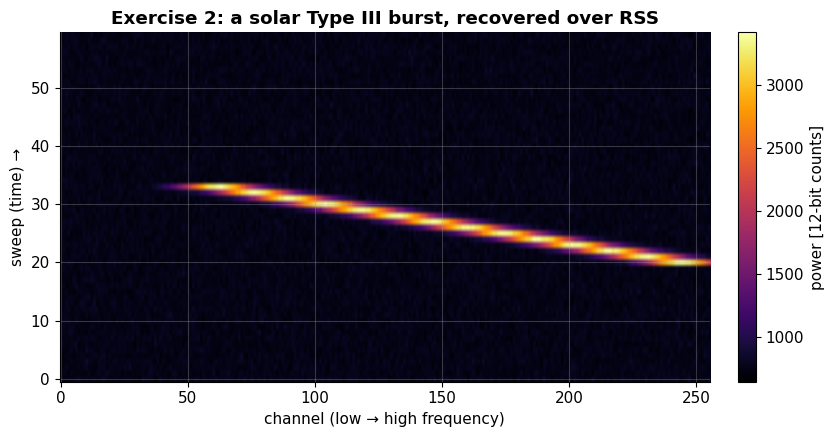

In [9]:
# Exercise 2: a fast frequency-drifting solar Type III burst.
S_NCHAN, S_NSWEEP = 256, 60
sc = np.arange(S_NCHAN)
solar = 750 + rng.normal(0, 30, (S_NSWEEP, S_NCHAN))
for t in range(S_NSWEEP):
    if 20 <= t < 34:                                  # the burst is brief
        # Drift from high channel (high freq) down to low channel as time advances.
        center = S_NCHAN - 12 - 14 * (t - 20)
        solar[t] += 2600 * np.exp(-0.5 * ((sc - center) / 10) ** 2)
solar = np.clip(solar, 0, formats.RSS_MAX_VALUE)

cfg, rec = stream_through_mock(solar, center_hz=20_100_000,
                               span_hz=4_000_000, n_channels=S_NCHAN)
assert np.array_equal(rec, np.rint(solar).astype(int))

fig, ax = plt.subplots(figsize=(8.5, 4.5))
im = ax.imshow(rec, aspect="auto", origin="lower", cmap="inferno")
ax.set_xlabel("channel (low → high frequency)")
ax.set_ylabel("sweep (time) →")
ax.set_title("Exercise 2: a solar Type III burst, recovered over RSS")
fig.colorbar(im, ax=ax, label="power [12-bit counts]", fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

**Exercise 3 — inspect the raw bytes of one sweep.** Use `encode_rss_sweep` directly to
see *exactly* what crosses the wire for a single sweep, and confirm the structure by
hand: `2*C` payload bytes + the `0xFE 0xFE` terminator, little-endian, high-channel
first. This is the byte stream `RSSClient.send_sweep` produces internally.

<details>
<summary>Solution</summary>

`encode_rss_sweep` produces *exactly* the bytes `RSSClient.send_sweep` puts on the wire.
For the toy sweep `[0, 1, 2, 4095]` (4 channels, given low→high, `4095 = 0x0FFF` is the
12-bit max):

```
ff 0f 02 00 01 00 00 00 fe fe
```

Reading it pair by pair makes every rule from §2 concrete:

| bytes   | uint16 (LoHi) | meaning                                 |
|---------|---------------|-----------------------------------------|
| `ff 0f` | `0x0FFF = 4095` | **highest** channel first; little-endian |
| `02 00` | `0x0002 = 2`    | next channel down                       |
| `01 00` | `0x0001 = 1`    | next channel down                       |
| `00 00` | `0x0000 = 0`    | **lowest** channel last                 |
| `fe fe` | —             | the `0xFE 0xFE` sweep terminator        |

Three structural facts to check by hand:

- **Length** is `2*C + 2 = 2*4 + 2 = 10` bytes (`2*C` payload + 2-byte terminator), so
  `blob.endswith(formats.RSS_TERMINATOR)` and `len(blob) == 10`.
- **Byte order is LoHi (little-endian):** `4095` stores as `ff 0f`, *not* `0f ff`
  (`(4095).to_bytes(2, "little") == b"\xff\x0f"`). The low byte leads.
- **Channel order is reversed:** the array is given low→high, but the wire is **highest
  channel first** — so `4095` (the last array element) leads the payload and `0`
  (the first) trails it. This is what makes the RSS waterfall put high frequency at one
  edge.

Finally `decode_rss_sweep` undoes both the byte order *and* the channel reversal, so it
round-trips back to the original low→high array: `[0, 1, 2, 4095]`.

</details>

In [10]:
# Exercise 3: dissect one sweep's bytes by hand.
toy = np.array([0, 1, 2, 0x0FFF])           # 4 channels, low->high, incl. 12-bit max
blob = formats.encode_rss_sweep(toy)        # what goes on the wire

print("channels (low->high):", toy.tolist())
print("encoded sweep        :", blob.hex(" "))
print(f"length               : {len(blob)} bytes = 2*{len(toy)} payload + 2 terminator")

# Structure check, byte by byte:
assert len(blob) == 2 * len(toy) + 2
assert blob.endswith(formats.RSS_TERMINATOR)               # last two bytes: fe fe
payload = blob[:-2]
# High channel first: value 0x0FFF (=4095) leads, stored little-endian as ff 0f.
assert payload[0:2] == b"\xff\x0f"
# Low channel last: value 0 trails, stored as 00 00.
assert payload[-2:] == b"\x00\x00"
print("\nFirst pair  ff 0f -> 0x0fff = 4095  (highest channel, LoHi byte order)")
print("Last pair   00 00 -> 0x0000 = 0     (lowest channel)")

# And it round-trips back to the original (low->high) order:
assert np.array_equal(formats.decode_rss_sweep(blob), toy)
print("decode_rss_sweep(blob) ==", formats.decode_rss_sweep(blob).tolist(), "(round-trips)")

channels (low->high): [0, 1, 2, 4095]
encoded sweep        : ff 0f 02 00 01 00 00 00 fe fe
length               : 10 bytes = 2*4 payload + 2 terminator

First pair  ff 0f -> 0x0fff = 4095  (highest channel, LoHi byte order)
Last pair   00 00 -> 0x0000 = 0     (lowest channel)
decode_rss_sweep(blob) == [0, 1, 2, 4095] (round-trips)


## Recap & what's next

- **RASDR** is an open, **LimeSDR-based amateur radio-astronomy receiver** from
  **myriadrf**. It channelises RF into power spectra and streams them — over a TCP
  socket — into a **display program**.
- That display program is usually **Radio-Sky Spectrograph (RSS)**, the de-facto
  amateur waterfall tool, serving the **Radio JOVE** community's Jupiter/Sun work.
- The **RASDR → RSS data path** is a tiny, unceremonious protocol: connect to
  **`127.0.0.1:8888`**, send the **`F|S|O|C`** handshake, then stream sweeps of
  **LoHi `uint16`** (12-bit) samples, **highest channel first**, each ended by
  **`0xFE 0xFE`**. No timestamps, no acks.
- We streamed a simulated **Jovian decametric storm** (and a solar Type III burst)
  through `jansky.formats`' `RSSClient` → `MockRSSServer`, recovered the dynamic
  spectrum **byte-for-byte**, and dissected a single sweep's raw bytes.
- The same `RSSClient` drives the **real** RSS unchanged — just point it at
  `127.0.0.1:8888` with **Options → Radio → RTL Bridge/TCP** selected.

**Where this connects:**

- [**Chapter 16 — Data Formats & the Ecosystem**](16_data_formats_and_ecosystem.ipynb)
  introduced the RSS protocol alongside GUPPI raw and SigMF, and explains why the
  `.sps`/`.spd` *file* readers are deliberately **deferred** (we don't guess binary
  layouts). This chapter went deeper on the *live* path.
- [**`docs/data-formats.md`**](https://github.com/joebarbere/jansky/blob/main/docs/data-formats.md)
  is the written spec for the protocol and the format landscape.
- [**`docs/projects.md`**](https://github.com/joebarbere/jansky/blob/main/docs/projects.md)
  is the hardware field guide — the **Radio JOVE** kit, SDRs (incl. LimeSDR), LNAs, and
  antennas that produce the spectra you'd feed through this very path.
- [**Chapter 23 — The Sun & Jupiter**](23_solar_and_jupiter.ipynb) covers the *science*
  of the decametric emission we simulated here.